# Complete Data Preprocessing Flow

Raw Data
    │
    ▼
Data Collection
    │
    ▼
Data Cleaning
    │
    ▼
Exploratory Data Analysis (EDA)
    │
    ▼
Data Transformation
    │
    ▼
Encoding Categorical Variables
    │
    ▼
Feature Engineering
    │
    ▼
Feature Selection
    │
    ▼
Handle Imbalanced Data (if needed)
    │
    ▼
Train-Test Split
    │
    ▼
Cross Validation
    │
    ▼
Ready for Model Training

## Phase 1: Data Ingestion

In [71]:
import pandas as pd

dc = pd.read_csv(r"D:\LEARNBAY\ALL ML PROJECTS\smartwatch_health-tracker\Smartwatch Health Analytics.csv")
dc.head()

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level,Stress Category
0,4174,58.939776,98.809650,5450.390578,7.167236,Highly Active,3,Low
1,5000,75.220601,98.532195,727.601610,6.538239,Highly Active,3,Low
2,1860,112.891259,97.052954,2826.521994,6.503308,Highly Active,10,High
3,2294,40.843362,96.894213,13797.338044,7.367790,Active,3,Low
4,2130,61.950165,98.583797,15679.067648,6.503308,Highly Active,1,Low


In [73]:
dc.shape

(10000, 8)

In [75]:
dc.columns

Index(['User ID', 'Heart Rate (BPM)', 'Blood Oxygen Level (%)', 'Step Count',
       'Sleep Duration (hours)', 'Activity Level', 'Stress Level',
       'Stress Category'],
      dtype='object')

In [81]:
dc["Stress Category"].unique()

array(['Low', 'High', 'Moderate'], dtype=object)

In [79]:
dc["Activity Level"].unique()

array(['Highly Active', 'Active', 'Sedentary', nan], dtype=object)

In [83]:
dc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User ID                 10000 non-null  int64  
 1   Heart Rate (BPM)        9500 non-null   float64
 2   Blood Oxygen Level (%)  9600 non-null   float64
 3   Step Count              9400 non-null   float64
 4   Sleep Duration (hours)  9500 non-null   float64
 5   Activity Level          9412 non-null   object 
 6   Stress Level            10000 non-null  int64  
 7   Stress Category         10000 non-null  object 
dtypes: float64(4), int64(2), object(2)
memory usage: 625.1+ KB


## Phase 2: Data Quality Assessment

In [85]:
print(dc.isnull().sum())

User ID                     0
Heart Rate (BPM)          500
Blood Oxygen Level (%)    400
Step Count                600
Sleep Duration (hours)    500
Activity Level            588
Stress Level                0
Stress Category             0
dtype: int64


In [87]:
# percentage of null data

print(dc.isnull().sum()/len(dc)*100)

User ID                   0.00
Heart Rate (BPM)          5.00
Blood Oxygen Level (%)    4.00
Step Count                6.00
Sleep Duration (hours)    5.00
Activity Level            5.88
Stress Level              0.00
Stress Category           0.00
dtype: float64


In [89]:
print(dc.describe())

            User ID  Heart Rate (BPM)  Blood Oxygen Level (%)    Step Count  \
count  10000.000000       9500.000000             9600.000000   9400.000000   
mean    3049.539900         75.308021               97.857042   6911.506911   
std     1176.241477         14.586042                1.686218   6513.740647   
min     1001.000000         40.843362               93.509172     71.312795   
25%     2016.000000         65.330039               96.709077   2057.073924   
50%     3040.000000         75.220601               98.010642   4962.534599   
75%     4072.250000         84.789257               99.330568   9695.505258   
max     5200.000000        112.891259              100.000000  31360.439203   

       Sleep Duration (hours)  Stress Level  
count             9500.000000  10000.000000  
mean                 6.505247      5.500000  
std                  1.455243      2.872425  
min                  3.073226      1.000000  
25%                  5.541962      3.000000  
50%         

## Phase 3: Data Cleaning

#### Here we need to clean the data by filling the missing value / removing unwanted charecters / imputing the values using mean-median-mode method.

#### 3.1 Replace Invalid Values

In [91]:
import numpy as np

dc["Sleep Duration (hours)"] = dc["Sleep Duration (hours)"].replace("ERROR", np.nan)

#### 3.2 Correct Category Labels

In [93]:
dc["Activity Level"] = dc["Activity Level"].replace({
    "Actve": "Active",
    "Seddentary": "Sedentary",
    "Highly_Active": "Highly Active"
})

#### 3.3 Convert Data Types

In [95]:
dc["Sleep Duration (hours)"] = pd.to_numeric(
    dc["Sleep Duration (hours)"],
    errors="coerce"
)

dc["Stress Level"] = pd.to_numeric(
    dc["Stress Level"],
    errors="coerce"
)

#### 3.4 Handle Missing Values - (Numerical Features)

In [97]:
num_cols = [
    "Heart Rate (BPM)",
    "Blood Oxygen Level (%)",
    "Step Count",
    "Sleep Duration (hours)"
]

for col in num_cols:
    dc[col].fillna(dc[col].median(), inplace=True)

C:\Users\bipul\AppData\Local\Temp\ipykernel_5616\3862854241.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dc[col].fillna(dc[col].median(), inplace=True)


#### (Categorical Features)

In [99]:
dc["Activity Level"].fillna(
    dc["Activity Level"].mode()[0],
    inplace=True
)

C:\Users\bipul\AppData\Local\Temp\ipykernel_5616\1293611483.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dc["Activity Level"].fillna(


In [101]:
dc.drop("User ID", axis=1, inplace=True)

## Phase 4: Exploratory Data Analysis

#### Missing Values

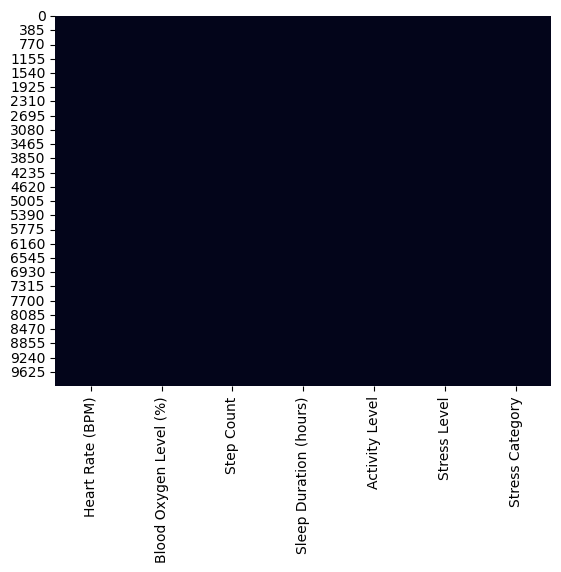

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(dc.isnull(), cbar=False)
plt.show()

In [ ]:
# As the target variable "Stress Level" has less then 2% Null values, it is recommended to drop the null rows for better result.

In [63]:
dc = dc.dropna(subset=["Stress Level"])

#### Distribution Analysis

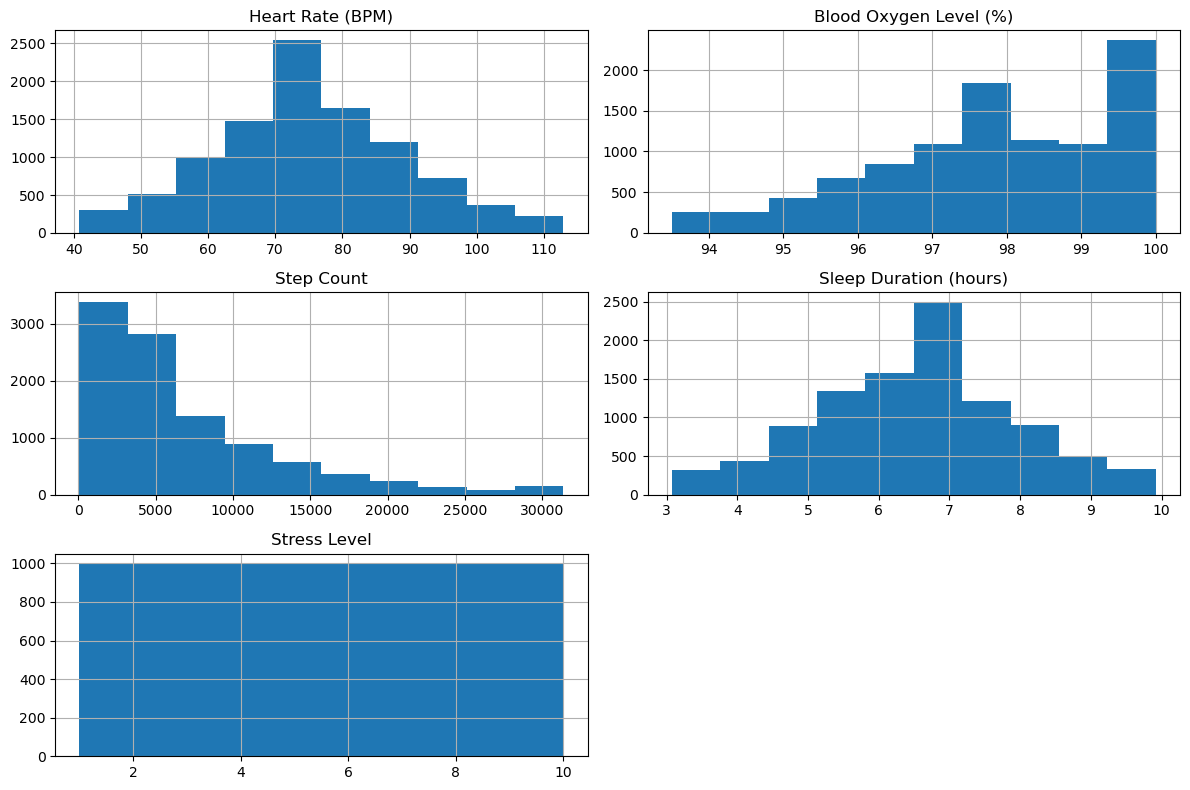

In [105]:
dc.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

#### Correlation Matrix

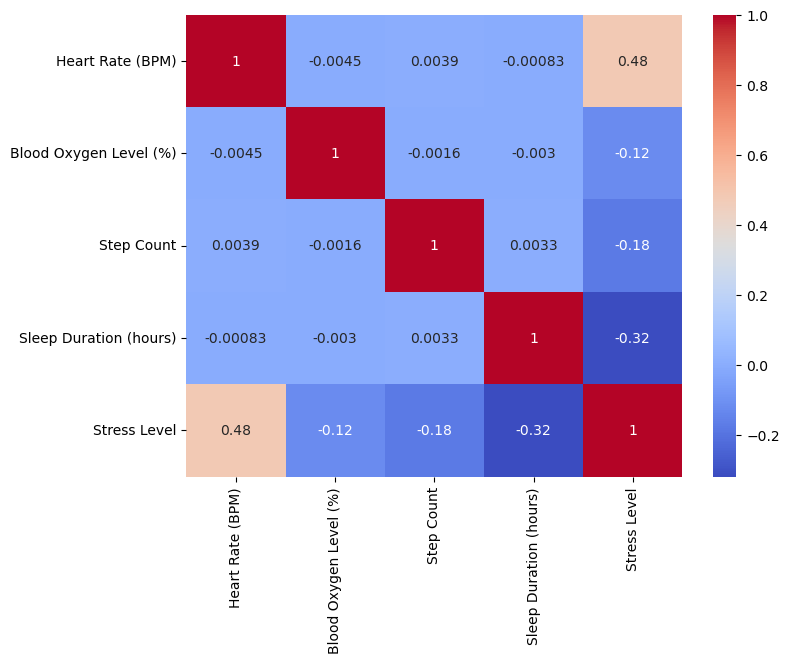

In [107]:
plt.figure(figsize=(8,6))

sns.heatmap(
    dc.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

#### Stress Level Distribution

In [ ]:
sns.countplot(x="Stress Level", data=dc)
plt.show()

## Phase 5: Outlier Treatment

#### IQR Method

In [109]:
def remove_outliers(dc, col):

    Q1 = dc[col].quantile(0.25)
    Q3 = dc[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return dc[(dc[col] >= lower) & (dc[col] <= upper)]

for col in num_cols:
    dc = remove_outliers(dc, col)

## Phase 6: Feature Engineering

#### Activity Encoding

In [111]:
activity_mapping = {
    "Sedentary": 0,
    "Active": 1,
    "Highly Active": 2
}

dc["Activity Level"] = dc["Activity Level"].map(activity_mapping)

#### One Hot Encoding

## Phase 7: Feature Selection

In [113]:
# Features

X = dc.drop(columns=["Stress Level", "Stress Category"], errors="ignore")

# Target
y = dc["Stress Level"]

In [115]:
# IMPORTANT: X is still a DataFrame
print("Before split:", type(X))

Before split: <class 'pandas.core.frame.DataFrame'>


## Phase 8: Train-Test Split

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", type(X_train))
print("X_test :", type(X_test))
print("Shape:", X_train.shape, X_test.shape)

X_train: <class 'pandas.core.frame.DataFrame'>
X_test : <class 'pandas.core.frame.DataFrame'>
Shape: (7497, 5) (1875, 5)


## Phase 9: Model Building

#### Baseline Model

In [119]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

#### Prediction

In [121]:
y_pred = rf.predict(X_test)

## Phase 10: Model Evaluation

In [123]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

Accuracy: 0.18453333333333333
              precision    recall  f1-score   support

           1       0.26      0.32      0.29       173
           2       0.17      0.20      0.18       182
           3       0.12      0.11      0.11       189
           4       0.13      0.11      0.12       189
           5       0.16      0.14      0.15       192
           6       0.10      0.09      0.10       191
           7       0.11      0.11      0.11       191
           8       0.18      0.14      0.16       193
           9       0.22      0.24      0.23       194
          10       0.34      0.41      0.38       181

    accuracy                           0.18      1875
   macro avg       0.18      0.19      0.18      1875
weighted avg       0.18      0.18      0.18      1875

[[56 35 34 16  8 11  8  2  3  0]
 [38 36 24 18 16 14 19  7  5  5]
 [36 29 20 27 19 20 17  5 10  6]
 [28 20 23 21 25 20 22 10 14  6]
 [19 23 17 27 26 16 20 15 13 16]
 [16 16 23 16 16 18 24 25 21 16]
 [12 24  9 16

## Phase 11: Hyperparameter Tuning

In [125]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100,200,300],
    "max_depth": [5,10,15],
    "min_samples_split": [2,5,10]}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


## Phase 12: Feature Importance

In [127]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                  Feature  Importance
0        Heart Rate (BPM)    0.257550
3  Sleep Duration (hours)    0.239902
2              Step Count    0.234878
1  Blood Oxygen Level (%)    0.207091
4          Activity Level    0.060579


## Phase 13: Save Pipeline

In [129]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
import joblib

joblib.dump(rf, "stress_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## Production-Ready Pipeline

#### Use a single Scikit-Learn Pipeline:

In [131]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric_features = [
    "Heart Rate (BPM)",
    "Blood Oxygen Level (%)",
    "Step Count",
    "Sleep Duration (hours)"
]

categorical_features = ["Activity Level"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Heart Rate (BPM)',
                                                   'Blood Oxygen Level (%)',
                                                   'Step Count',
                                                   'Sleep Duration (hours)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Activity Level'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

## Project Title:

Smartwatch Health Analytics: Stress Level Prediction Using Machine Learning
.

## Business Objective:

Predict a user's stress level using smartwatch health metrics such as heart rate, blood oxygen level, sleep duration, activity level, and step count to enable proactive health monitoring and wellness recommendations.
is the type of end-to-end pipeline expected from an ML Engineer in interviews and portfolio projects